In [4]:
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent.parent))

from spinspiral import construct_full

theta, phi      = 0, 0
path_to_cif     = "1MnTe2-2.cif"
Q               = [1/3, 1/3, 0]
magnetic_magnitude =  2.8
P = np.array([
    [2,  1, 0],
    [-1, 1, 0],
    [0,  0, 1]
])
magnetic_atom   = 'Mn'
init_moment     = [0, magnetic_magnitude, 0]


supercell, name = construct_full(
    theta=theta, phi=phi, Q=Q,
    path=path_to_cif,
    transform=P,
    magnitude=magnetic_magnitude,
    magsymbols=magnetic_atom,
    init_moment=init_moment,
)

supercell.arrays

n_hat = [0. 0. 1.]
Initial moment= [0.  2.8 0. ]


{'numbers': array([25, 52, 52, 25, 52, 52, 25, 52, 52]),
 'positions': array([[ 0.00000000e+00,  0.00000000e+00,  9.11269134e+00],
        [ 1.83003250e+00,  1.05656975e+00,  1.07572768e+01],
        [ 1.83003250e+00,  1.05656975e+00,  7.46810604e+00],
        [-1.83003250e+00,  3.16970926e+00,  9.11269134e+00],
        [-9.98467789e-16,  4.22627902e+00,  1.07572768e+01],
        [-9.98467789e-16,  4.22627902e+00,  7.46810604e+00],
        [ 1.83003250e+00,  3.16970926e+00,  9.11269134e+00],
        [-1.83003250e+00,  1.05656975e+00,  1.07572768e+01],
        [-1.83003250e+00,  1.05656975e+00,  7.46810604e+00]]),
 'spacegroup_kinds': array([0, 1, 2, 0, 1, 2, 0, 1, 2]),
 'initial_magmoms': array([[ 0.        ,  2.8       ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 2.42487113, -1.4       ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [

In [5]:
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from spinspiral import construct_full

theta, phi      = 0, 0
path_to_cif     = "1MnTe2-2.cif"
Q               = [-1/3, -1/3, 0]
magnetic_magnitude =  2.8
P = np.array([
    [2,  1, 0],
    [-1, 1, 0],
    [0,  0, 1]
])
magnetic_atom   = 'Mn'
init_moment     = [0, magnetic_magnitude, 0]


supercell, name = construct_full(
    theta=theta, phi=phi, Q=Q,
    path=path_to_cif,
    transform=P,
    magnitude=magnetic_magnitude,
    magsymbols=magnetic_atom,
    init_moment=init_moment,
)

supercell.arrays

n_hat = [0. 0. 1.]
Initial moment= [0.  2.8 0. ]


{'numbers': array([25, 52, 52, 25, 52, 52, 25, 52, 52]),
 'positions': array([[ 0.00000000e+00,  0.00000000e+00,  9.11269134e+00],
        [ 1.83003250e+00,  1.05656975e+00,  1.07572768e+01],
        [ 1.83003250e+00,  1.05656975e+00,  7.46810604e+00],
        [-1.83003250e+00,  3.16970926e+00,  9.11269134e+00],
        [-9.98467789e-16,  4.22627902e+00,  1.07572768e+01],
        [-9.98467789e-16,  4.22627902e+00,  7.46810604e+00],
        [ 1.83003250e+00,  3.16970926e+00,  9.11269134e+00],
        [-1.83003250e+00,  1.05656975e+00,  1.07572768e+01],
        [-1.83003250e+00,  1.05656975e+00,  7.46810604e+00]]),
 'spacegroup_kinds': array([0, 1, 2, 0, 1, 2, 0, 1, 2]),
 'initial_magmoms': array([[ 0.        ,  2.8       ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [-2.42487113, -1.4       ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [

In [6]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# Using difference between CW and CCW spirals

## OBS there is something weird here. The sign is wrong

In [7]:
def loader(csv_file):
    kgrid_vals = []
    k_energy   = []
    k_mn_mom   = []

    ecut_vals  = []
    e_energy   = []
    e_mn_mom   = []

    with open(csv_file, 'r') as f:
        reader = csv.DictReader(f)

        for row in reader:
            #NOTE skipping first point as it skews the viewing of the results.
            if row['kgrid'] == "1x1x1":
                continue
            if row["scf_converged"] != "True":
                continue

            # energy = float(row["energy_per_atom_eV"])
            energy = float(row["energy_eV"]) /3
            #NOTE trying with total energy per primitive cell to see results more clearly (Afraid of rounding errors)

            mn_list = [float(x) for x in row["mn_moment_magnitudes"].split('|')]
            mn_mean = np.mean(mn_list)

            if row["phase"] == "kconv":
                k = int(row["kgrid"].split('x')[0])
                kgrid_vals.append(k)
                k_energy.append(energy)
                k_mn_mom.append(mn_mean)

            elif row["phase"] == "econv":
                ecut = float(row["ecut_eV"])
                ecut_vals.append(ecut)
                e_energy.append(energy)
                e_mn_mom.append(mn_mean)

    # Sort
    kgrid_vals, k_energy, k_mn_mom = zip(*sorted(zip(kgrid_vals, k_energy, k_mn_mom)))
    ecut_vals,  e_energy,  e_mn_mom = zip(*sorted(zip(ecut_vals, e_energy, e_mn_mom)))

    return [kgrid_vals, k_energy,k_mn_mom , ecut_vals,  e_energy,  e_mn_mom]

In [8]:
# def loader(csv_file):
#     k_data   = {}   # k -> (energy, mn_mean)
#     e_data   = {}   # ecut -> (energy, mn_mean)

#     with open(csv_file, 'r') as f:
#         reader = csv.DictReader(f)
#         for row in reader:
#             # Skip repeated header rows that snuck in as data
#             if row['phase'] == 'phase':
#                 continue
#             if row['kgrid'] == "1x1x1":
#                 continue
#             if row["scf_converged"] != "True":
#                 continue

#             energy  = float(row["energy_eV"]) / 3
#             mn_list = [float(x) for x in row["mn_moment_magnitudes"].split('|')]
#             mn_mean = np.mean(mn_list)

#             if row["phase"] == "kconv":
#                 k = int(row["kgrid"].split('x')[0])
#                 k_data[k] = (energy, mn_mean)          # last write wins (or use first-seen)

#             elif row["phase"] == "econv":
#                 ecut = float(row["ecut_eV"])
#                 e_data[ecut] = (energy, mn_mean)

#     # Unpack sorted
#     k_sorted   = sorted(k_data.items())
#     e_sorted   = sorted(e_data.items())

#     kgrid_vals = [k        for k, _      in k_sorted]
#     k_energy   = [v[0]     for _, v      in k_sorted]
#     k_mn_mom   = [v[1]     for _, v      in k_sorted]

#     ecut_vals  = [e        for e, _      in e_sorted]
#     e_energy   = [v[0]     for _, v      in e_sorted]
#     e_mn_mom   = [v[1]     for _, v      in e_sorted]

#     return [kgrid_vals, k_energy, k_mn_mom, ecut_vals, e_energy, e_mn_mom]

In [9]:
def plot_convergence(results, save=False, filename='update_name.pdf'):
    kgrid_vals, k_energy,k_mn_mom , ecut_vals,  e_energy,  e_mn_mom = results

    # Compute global min/max for Mn moments (For later "share y" axis effect)
    mn_all = np.concatenate([k_mn_mom, e_mn_mom])
    mn_min = np.min(mn_all)
    mn_max = np.max(mn_all)

    padding = 0.02 * (mn_max - mn_min) if mn_max > mn_min else 0.1

    # =========================
    # 1 row × 2 columns, shared energy axis
    # =========================
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    labelsize=12
    titlesize=16

    # ----- Left: k-point convergence -----
    ax2 = ax1.twinx()
    ax4 = ax3.twinx()

    ax1.plot(kgrid_vals, np.array(k_energy)*10**3, marker='o' , label = r'Energy', color='black')
    ax2.plot(kgrid_vals, k_mn_mom, marker='s', label = r'Mn $\mu$B', color='red')
    

    ax1.set_xlabel(r"$k$-grid (NxN)", fontsize=labelsize)
    ax1.set_ylabel(r"$\Delta E$ per primitive cell (meV)", fontsize=labelsize)
    # ax2.set_ylabel("Mn magnetic moment (µB)") #Maybe comment out this

    ax1.set_title(r"$k$-point convergence", fontsize=titlesize)

    # ----- Right: cutoff convergence -----

    ax3.plot(ecut_vals, np.array(e_energy)*10**3, marker='o', color='black')
    ax4.plot(ecut_vals, e_mn_mom, marker='s', color='red')

    ax3.set_xlabel("PW cutoff (eV)", fontsize=labelsize)
    ax4.set_ylabel("Avg. Mn magmom (µB)", fontsize=labelsize)

    ax3.set_title("PW cutoff convergence", fontsize=titlesize)


    #Share y-axes of the Mn magnetic moment stuff
    ax2.set_ylim(mn_min - padding, mn_max + padding)
    ax4.set_ylim(mn_min - padding, mn_max + padding)

    ax2.set_yticks([])

    
    handles,labels = [], []
    for ax in [ax1,ax2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    # fig.legend(handles,labels,loc=(0.1,1/2))
    fig.legend(handles,labels,loc=(1/2-0.2,0.75))
    # fig.legend(handles,labels,loc=(0,0))

    plt.tight_layout()
    fig.subplots_adjust(wspace=0)
    if save:
        plt.savefig(filename)
    plt.show()



def plot_convergence_3(results, save=False, filename='update_name.pdf'):
    kgrid_vals, k_energy,k_mn_mom , ecut_vals,  e_energy,  e_mn_mom = results

    # Compute global min/max for Mn moments (For later "share y" axis effect)
    mn_all = np.concatenate([k_mn_mom, e_mn_mom])
    mn_min = np.min(mn_all)
    mn_max = np.max(mn_all)

    padding = 0.02 * (mn_max - mn_min) if mn_max > mn_min else 0.1

    # =========================
    # 1 row × 2 columns, shared energy axis
    # =========================
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
    labelsize=12
    titlesize=16

    # ----- Left: k-point convergence -----
    ax2 = ax1.twinx()
    ax4 = ax3.twinx()

    ax1.plot(kgrid_vals, np.array(k_energy)*10**3, marker='o' , label = r'Energy', color='black')
    ax2.plot(kgrid_vals, np.array(k_mn_mom), marker='s', label = r'Mn $\mu$B', color='red')
    

    ax1.set_xlabel(r"$k$-grid (NxN)", fontsize=labelsize)
    ax1.set_ylabel(r"$\Delta E$ per primitive cell (meV)", fontsize=labelsize)
    # ax2.set_ylabel("Mn magnetic moment (µB)") #Maybe comment out this

    ax1.set_title(r"$k$-point convergence", fontsize=titlesize)

    # ----- Right: cutoff convergence -----

    ax3.plot(ecut_vals, np.array(e_energy)*10**3, marker='o', color='black')
    ax4.plot(ecut_vals, e_mn_mom, marker='s', color='red')

    ax3.set_xlabel("PW cutoff (eV)", fontsize=labelsize)
    ax4.set_ylabel("Avg. Mn magmom (µB)", fontsize=labelsize)

    ax3.set_title("PW cutoff convergence", fontsize=titlesize)


    # ##Share y-axes of the Mn magnetic moment stuff
    # ax2.set_ylim(mn_min - padding, mn_max + padding)
    # ax4.set_ylim(mn_min - padding, mn_max + padding)

    # ax2.set_yticks([])

    
    handles,labels = [], []
    for ax in [ax1,ax2]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    # fig.legend(handles,labels,loc=(0,0))
    fig.legend(handles,labels,loc=(1/2-0.2,0.75))

    plt.tight_layout()
    # fig.subplots_adjust(wspace=0)
    if save:
        plt.savefig(filename)
    plt.show()

In [10]:
# #uncomment when latex plot is desired
from matplotlib import rc
rc('text', usetex=True) 
rc('font', family='serif')

In [11]:
CW = loader(csv_file='convergence_results_cw.csv')
CCW = loader(csv_file='convergence_results_ccw.csv')

In [12]:
k_energy_diff = np.array(CCW[1]) - np.array(CW[1])

e_energy_diff = np.array(CCW[4]) - np.array(CW[4])

In [13]:
k_energy_diff

array([-0.02170233, -0.02170233, -0.02170233, -0.02170233, -0.02170233,
       -0.02170233, -0.02170233, -0.02170233, -0.02170233, -0.02170233,
       -0.02170233, -0.02170233, -0.02170233, -0.02170233, -0.02170233,
       -0.02170233, -0.02416633, -0.02416633, -0.02416633, -0.02416633,
       -0.02416633, -0.02416633, -0.02416633, -0.02416633, -0.02416633,
       -0.02416633, -0.02416633, -0.02416633, -0.02416633, -0.02416633,
       -0.02416633, -0.02416633, -0.02535333, -0.02535333, -0.02535333,
       -0.02535333, -0.02535333, -0.02535333, -0.02535333, -0.02535333,
       -0.02535333, -0.02535333, -0.02535333, -0.02535333, -0.02535333,
       -0.02535333, -0.02535333, -0.02535333, -0.025624  , -0.025624  ,
       -0.025624  , -0.025624  , -0.025624  , -0.025624  , -0.025624  ,
       -0.025624  , -0.025624  , -0.025624  , -0.025624  , -0.025624  ,
       -0.025624  , -0.025624  , -0.025624  , -0.025624  , -0.02542467,
       -0.02546533])

In [14]:
(0.025624-0.02535333)*10**3

0.27067000000000063

In [15]:
difference = [CCW[0], k_energy_diff , CCW[2] , CCW[3] , e_energy_diff , CCW[5]]

In [16]:
# plot_convergence(difference)

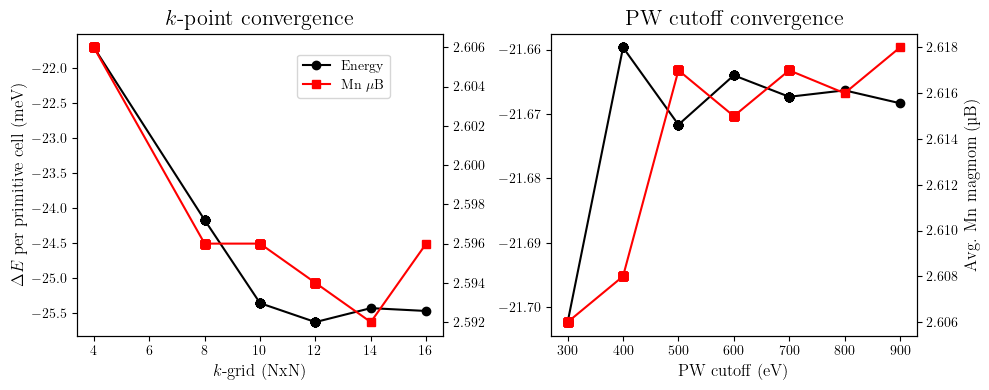

In [17]:
plot_convergence_3(difference, save=False, filename='MnTe2_convergence_1.png')

ccw:

econv,ecut_800eV,4x4x1,800,-56.631103,-6.292345,-0.0,2.616|2.616|2.616,True,
econv,ecut_900eV,4x4x1,900,-56.631144,-6.292349,-0.0,2.618|2.618|2.618,True,


cw:

econv,ecut_800eV,4x4x1,800,-56.566104,-6.285123,-0.0,2.621|2.621|2.621,True,
econv,ecut_900eV,4x4x1,900,-56.566139,-6.285127,-0.0,2.621|2.621|2.621,True,